In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('../../data/dataset_satelit.csv')

df.head()


,No,Longitude,Lattitude,N,P,K,Ca,Mg,Fe,Mn,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
0,1,103.036658,-0.604417,2.64,0.15,0.415,0.51,0.31,119.96,463.23,...,0.0433,0.18183,0.04461,35.74446,35.79744,35.41161,0.22331,0.05479,0.31325,0.07686
1,2,103.037201,-0.604689,2.75,0.17,0.568,0.76,0.58,102.63,493.81,...,0.0465,0.22079,0.04640,35.12096,35.14591,35.41510,0.27116,0.05699,0.38033,0.07993
2,3,103.036359,-0.603012,1.77,0.12,0.339,0.49,0.6,107.37,460.93,...,0.0417,0.18926,0.03992,35.07724,35.07730,35.41135,0.23242,0.04902,0.32604,0.06876
3,4,103.036950,-0.603219,2.30,0.15,0.460,0.74,0.67,96.02,338.17,...,0.0367,0.14769,0.03622,36.08078,36.08469,35.41583,0.18138,0.04448,0.25440,0.06238
4,5,103.036802,-0.601969,2.05,0.14,0.308,0.64,0.72,87.01,384.33,...,0.0361,0.18205,0.03797,32.68855,32.69293,35.41592,0.22359,0.04664,0.31359,0.06541


## 2. Informasi Dataset

In [3]:
print("Shape dataset:", df.shape)
print("\nInfo dataset:")
print(df.info())
print("\nStatistik deskriptif:")
df.describe()

Shape dataset: (594, 34)

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   No         594 non-null    int64  
 1   Longitude  594 non-null    float64
 2   Lattitude  594 non-null    float64
 3   N          594 non-null    float64
 4   P          594 non-null    float64
 5   K          593 non-null    float64
 6   Ca         594 non-null    float64
 7   Mg         594 non-null    object 
 8   Fe         594 non-null    float64
 9   Mn         594 non-null    float64
 10  Cu         594 non-null    float64
 11  Zn         594 non-null    float64
 12  B          594 non-null    float64
 13  b12        594 non-null    float64
 14  b11        594 non-null    float64
 15  b9         594 non-null    float64
 16  b8a        594 non-null    float64
 17  b8         594 non-null    float64
 18  b7         594 non-null    float64
 19  b6        

,No,Longitude,Lattitude,N,P,K,Ca,Fe,Mn,Cu,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
count,594.000000,594.000000,594.000000,594.000000,594.000000,593.000000,594.000000,594.000000,594.000000,594.000000,...,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000
mean,297.500000,106.878644,-1.024933,2.259091,0.141380,0.582175,0.595094,74.613771,308.034697,2.391195,...,0.177291,0.234474,0.102789,28.640422,28.664891,28.609569,0.202587,0.051524,0.269642,0.062320
std,171.617307,4.949840,0.965349,0.395499,0.019782,0.222567,0.366118,55.579655,241.731643,1.580296,...,0.155615,0.070516,0.112310,15.325347,15.380384,15.329170,0.104357,0.012959,0.143728,0.024218
min,1.000000,102.760857,-2.333750,1.140000,0.090000,0.122000,0.050000,21.080000,3.160000,0.090000,...,0.014100,0.115170,0.021460,0.127000,0.098600,0.026000,0.008700,0.016900,0.009300,0.016300
25%,149.250000,102.927811,-2.233338,1.982500,0.130000,0.429000,0.320000,40.705000,124.015000,1.172500,...,0.046925,0.183210,0.039535,31.959745,31.968948,33.685353,0.183085,0.040250,0.244935,0.052772
50%,297.500000,103.581969,-0.602276,2.280000,0.140000,0.549000,0.540000,65.650000,239.445000,2.225000,...,0.072700,0.213385,0.046550,35.067930,35.110415,34.611565,0.233590,0.050415,0.310380,0.068380
75%,445.750000,113.403797,-0.257349,2.570000,0.150000,0.710000,0.790000,87.372500,434.990000,3.357500,...,0.318900,0.262242,0.059190,38.319135,38.441065,39.002760,0.271790,0.060410,0.364505,0.079020
max,594.000000,113.434700,0.069251,3.230000,0.220000,1.489000,2.820000,559.100000,2009.320000,8.170000,...,0.751400,0.512210,0.373000,47.592900,48.014640,39.209330,0.658960,0.122300,0.814170,0.150620


In [4]:
# melihat kolom dataset
print("Kolom dataset:", df.columns.to_list())

Kolom dataset: ['No', 'Longitude', 'Lattitude', 'N', 'P', 'K', 'Ca', 'Mg', 'Fe', 'Mn', 'Cu', 'Zn', 'B', 'b12', 'b11', 'b9', 'b8a', 'b8', 'b7', 'b6', 'b5', 'b4', 'b3', 'b2', 'b1', 'Sigma_VV', 'Sigma_VH', 'plia', 'lia', 'iafe', 'gamma0_vv', 'gamma0_vh', 'beta0_vv', 'beta0_vh']


## 3. Analisis Korelasi

In [5]:
# Hitung korelasi antar variabel
correlation = df.corr(numeric_only=True)
print("Matriks Korelasi:")
print(correlation)

Matriks Korelasi:
                 No  Longitude  Lattitude         N         P         K  \
No         1.000000   0.298329  -0.048248  0.057689  0.103043  0.184023   
Longitude  0.298329   1.000000  -0.954575 -0.695291 -0.284783  0.437909   
Lattitude -0.048248  -0.954575   1.000000  0.742794  0.314183 -0.449305   
N          0.057689  -0.695291   0.742794  1.000000  0.643212 -0.138219   
P          0.103043  -0.284783   0.314183  0.643212  1.000000  0.113762   
K          0.184023   0.437909  -0.449305 -0.138219  0.113762  1.000000   
Ca         0.063824  -0.004674   0.038478  0.035696  0.114508 -0.088435   
Fe        -0.291045  -0.511479   0.431759  0.338775  0.214960 -0.192682   
Mn        -0.339729  -0.538369   0.485494  0.383059  0.084432 -0.366838   
Cu         0.098028   0.137537  -0.114330  0.028677 -0.016710  0.200614   
Zn        -0.489785  -0.371780   0.305065  0.186446 -0.000292 -0.312304   
B          0.007815  -0.159857   0.168161  0.122336  0.078215 -0.135192   
b12    

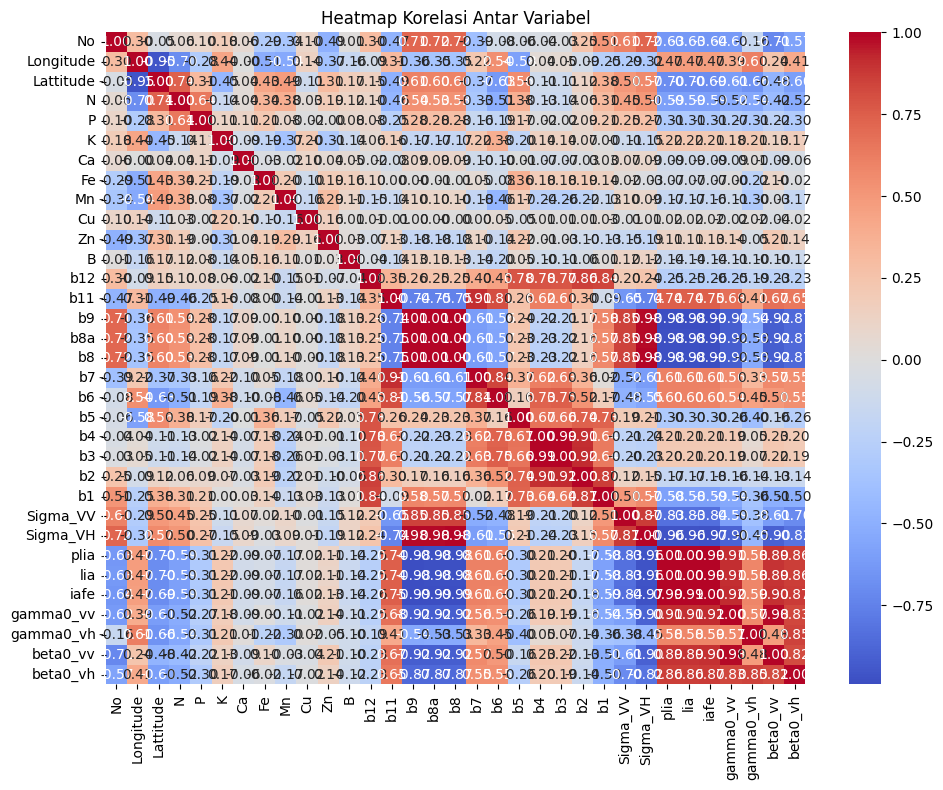

In [6]:
# Visualisasi heatmap korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Heatmap Korelasi Antar Variabel')
plt.tight_layout()
plt.show()

## 4. Persiapan Data

In [7]:
# Cek missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nJumlah total missing values:", df.isnull().sum().sum())

Missing Values:
No           0
Longitude    0
Lattitude    0
N            0
P            0
K            1
Ca           0
Mg           0
Fe           0
Mn           0
Cu           0
Zn           0
B            0
b12          0
b11          0
b9           0
b8a          0
b8           0
b7           0
b6           0
b5           0
b4           0
b3           0
b2           0
b1           0
Sigma_VV     0
Sigma_VH     0
plia         0
lia          0
iafe         0
gamma0_vv    0
gamma0_vh    0
beta0_vv     0
beta0_vh     0
dtype: int64

Jumlah total missing values: 1


In [8]:
df.columns

Index(['No', 'Longitude', 'Lattitude', 'N', 'P', 'K', 'Ca', 'Mg', 'Fe', 'Mn',
       'Cu', 'Zn', 'B', 'b12', 'b11', 'b9', 'b8a', 'b8', 'b7', 'b6', 'b5',
       'b4', 'b3', 'b2', 'b1', 'Sigma_VV', 'Sigma_VH', 'plia', 'lia', 'iafe',
       'gamma0_vv', 'gamma0_vh', 'beta0_vv', 'beta0_vh'],
      dtype='object')

In [9]:
# Pisahkan fitur (X) dan target (y)
# Asumsikan kolom 'N' sebagai target (kadar Nitrogen)
# Fitur: semua kolom kecuali 'No' dan 'N'

X = df.drop(['No', 'N', 'P', 'K', 'Ca', 'Mg', 'Fe', 'Mn',
       'Cu', 'Zn', 'B'], axis=1)
y = df['N']

print("Shape fitur (X):", X.shape)
print("Shape target (y):", y.shape)
print("\nNama fitur:")
print(X.columns.tolist())

Shape fitur (X): (594, 23)
Shape target (y): (594,)

Nama fitur:
['Longitude', 'Lattitude', 'b12', 'b11', 'b9', 'b8a', 'b8', 'b7', 'b6', 'b5', 'b4', 'b3', 'b2', 'b1', 'Sigma_VV', 'Sigma_VH', 'plia', 'lia', 'iafe', 'gamma0_vv', 'gamma0_vh', 'beta0_vv', 'beta0_vh']


In [10]:
# Split data menjadi training set dan testing set (80:20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print("Data Training:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print("\nData Testing:")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Data Training:
X_train shape: (475, 23)
y_train shape: (475,)

Data Testing:
X_test shape: (119, 23)
y_test shape: (119,)


## 5. Membangun Model OLS (Ordinary Least Squares)

In [11]:
# Import library untuk OLS
import statsmodels.api as sm

# Imputasi missing value pada fitur menggunakan median dari X_train
numeric_cols = X_train.select_dtypes(include=['number']).columns
for col in numeric_cols:
	median = X_train[col].median()
	X_train[col] = X_train[col].fillna(median)
	X_test[col] = X_test[col].fillna(median)

# Tambahkan konstanta (intercept) ke fitur
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Pastikan semua matriks input bertipe numerik float
X_train_const = X_train_const.astype(float)
X_test_const = X_test_const.astype(float)

# Bangun model OLS
model_ols = sm.OLS(y_train.astype(float), X_train_const)
results_ols = model_ols.fit()

# Tampilkan summary model
print(results_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      N   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                     31.00
Date:                Sat, 08 Nov 2025   Prob (F-statistic):           4.58e-78
Time:                        09:07:12   Log-Likelihood:                -8.0909
No. Observations:                 475   AIC:                             64.18
Df Residuals:                     451   BIC:                             164.1
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.2305      4.265      1.461      0.1

## 6. Evaluasi Model

In [12]:
# Prediksi pada data testing
y_pred = results_ols.predict(X_test_const)

# Hitung metrik evaluasi
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Evaluasi Model OLS ===")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

=== Evaluasi Model OLS ===
R-squared (R²): 0.5550
Mean Squared Error (MSE): 0.0674
Root Mean Squared Error (RMSE): 0.2596
Mean Absolute Error (MAE): 0.2009


## 7. Visualisasi Hasil Prediksi

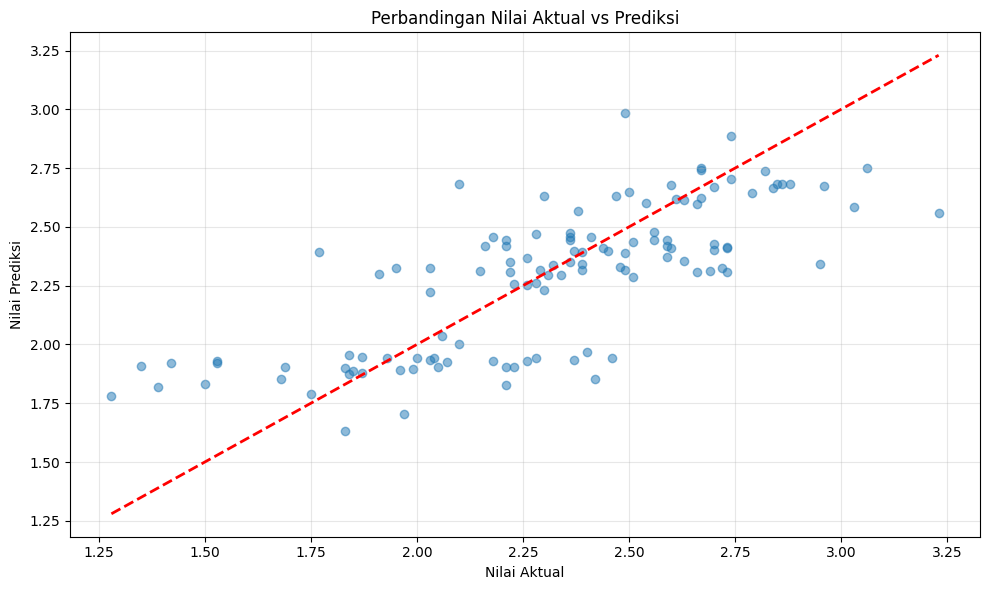

In [13]:
# Scatter plot: Nilai aktual vs Prediksi
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Perbandingan Nilai Aktual vs Prediksi')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Analisis Residual

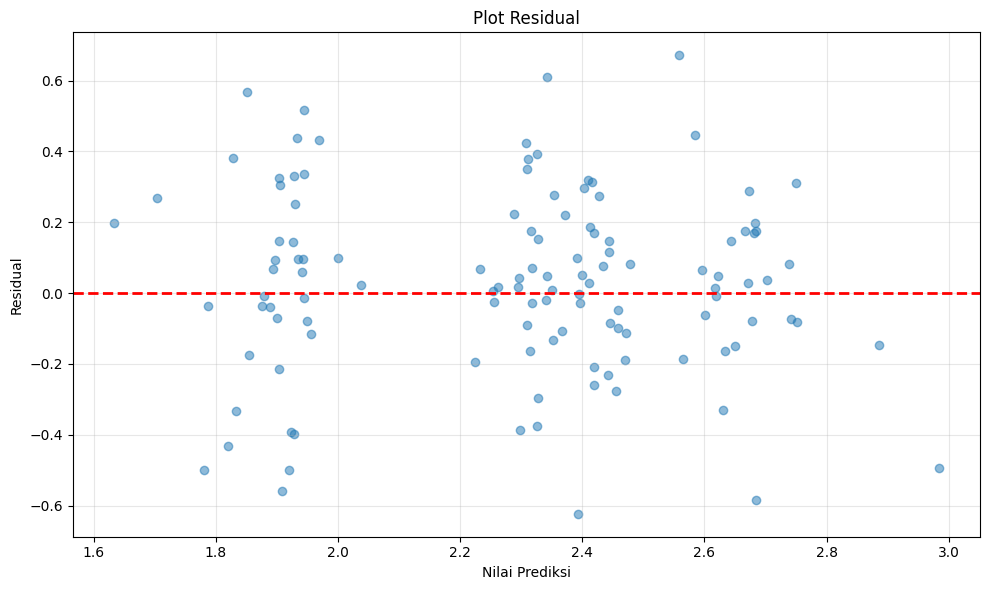

In [14]:
# Hitung residual
residuals = y_test - y_pred

# Plot residual vs nilai prediksi
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Nilai Prediksi')
plt.ylabel('Residual')
plt.title('Plot Residual')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

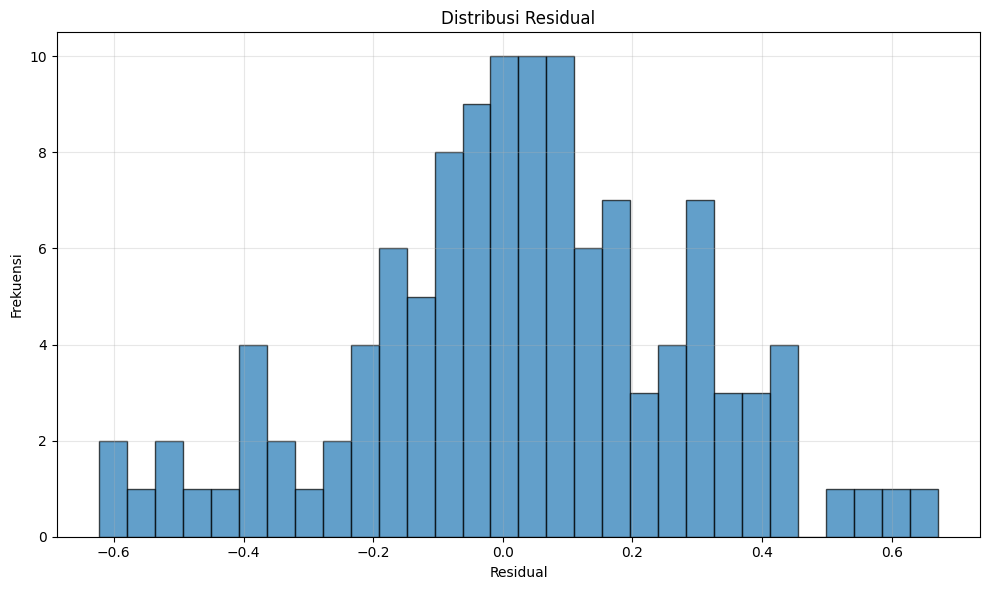

In [15]:
# Histogram residual
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residual')
plt.ylabel('Frekuensi')
plt.title('Distribusi Residual')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

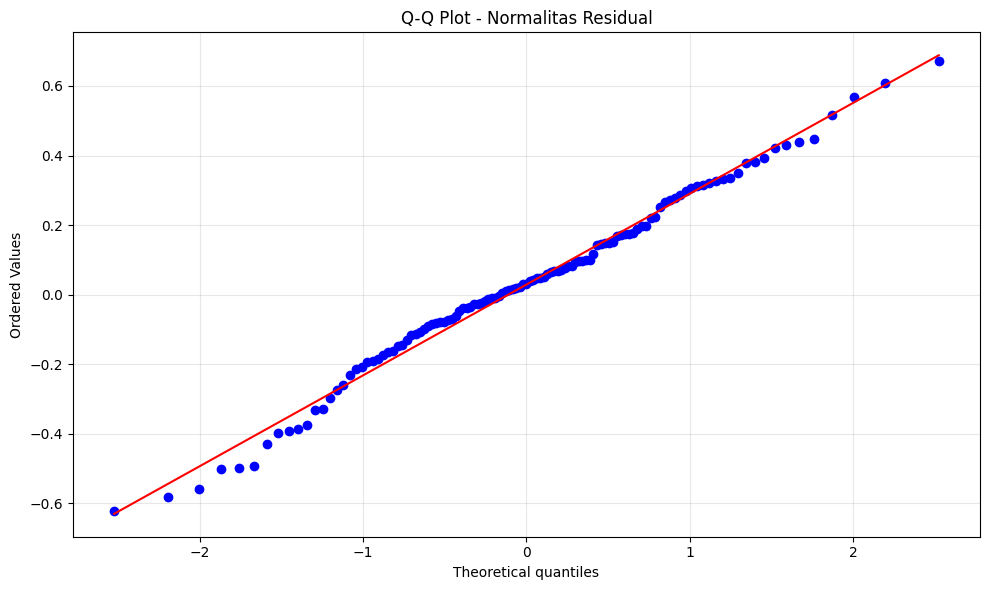

In [16]:
# Q-Q Plot untuk menguji normalitas residual
from scipy import stats

plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot - Normalitas Residual')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Interpretasi Koefisien

In [17]:
# Buat DataFrame untuk koefisien
coefficients = pd.DataFrame({
    'Fitur': X_train_const.columns,
    'Koefisien': results_ols.params,
    'P-value': results_ols.pvalues
})

# Urutkan berdasarkan nilai absolut koefisien
coefficients['Abs_Coef'] = coefficients['Koefisien'].abs()
coefficients = coefficients.sort_values('Abs_Coef', ascending=False)
coefficients = coefficients.drop('Abs_Coef', axis=1)

print("=== Koefisien Model OLS ===")
print(coefficients.to_string(index=False))

=== Koefisien Model OLS ===
    Fitur  Koefisien  P-value
       b3  -6.403458 0.013467
    const   6.230469 0.144756
       b4   5.493532 0.000405
       b7   2.891695 0.000117
gamma0_vv  -2.269529 0.468353
       b2   2.071575 0.139399
 beta0_vv   2.019400 0.374068
       b5  -1.966798 0.005049
      b11  -1.506284 0.059794
       b6  -1.499261 0.034334
      b12   0.831931 0.315001
 Sigma_VV  -0.502018 0.724910
gamma0_vh  -0.377885 0.955553
 beta0_vh   0.283955 0.956162
 Sigma_VH  -0.154010 0.905673
      b8a   0.049925 0.597103
     plia  -0.046700 0.671056
      lia   0.040575 0.710870
       b8  -0.036204 0.584506
       b9  -0.031295 0.738869
Longitude  -0.026766 0.653503
     iafe  -0.026657 0.701926
       b1  -0.009422 0.984837
Lattitude   0.006496 0.975487


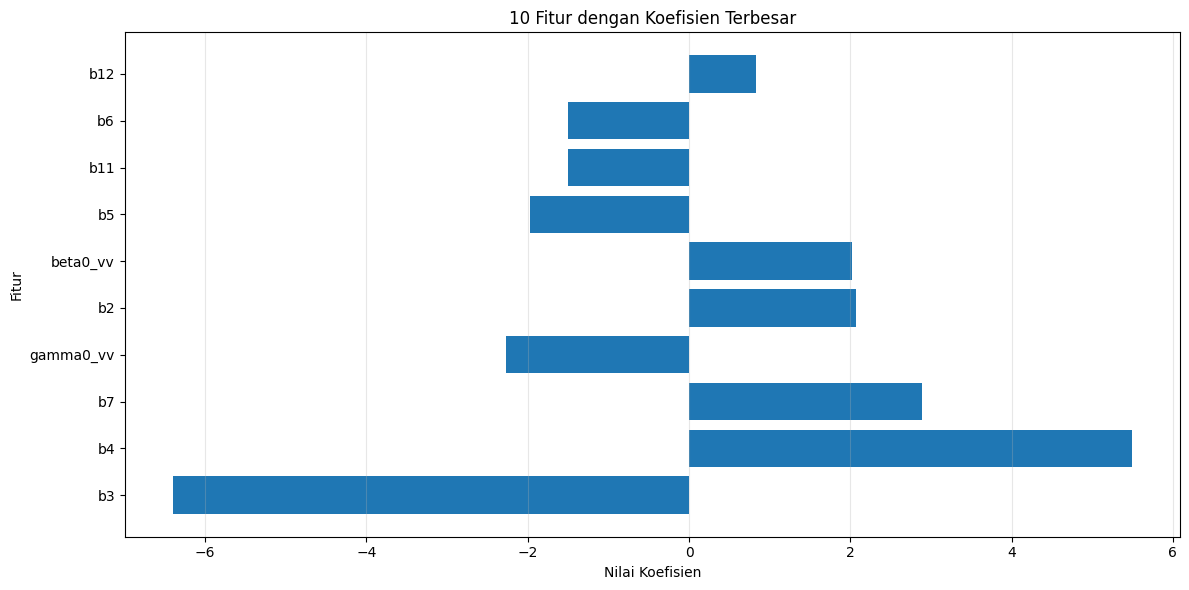

In [18]:
# Visualisasi fitur yang paling berpengaruh (10 teratas)
top_features = coefficients[coefficients['Fitur'] != 'const'].head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_features['Fitur'], top_features['Koefisien'])
plt.xlabel('Nilai Koefisien')
plt.ylabel('Fitur')
plt.title('10 Fitur dengan Koefisien Terbesar')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 10. Prediksi pada Data Baru

In [19]:
# Ambil contoh data untuk prediksi (5 baris pertama dari test set)
sample_data = X_test.head(5)
sample_actual = y_test.head(5)

# Tambahkan konstanta
sample_data_const = sm.add_constant(sample_data)

# Lakukan prediksi
sample_predictions = results_ols.predict(sample_data_const)

# Tampilkan hasil
comparison = pd.DataFrame({
    'Nilai Aktual': sample_actual.values,
    'Nilai Prediksi': sample_predictions.values,
    'Selisih': abs(sample_actual.values - sample_predictions.values)
})

print("=== Perbandingan Prediksi vs Aktual ===")
print(comparison.to_string(index=False))

=== Perbandingan Prediksi vs Aktual ===
 Nilai Aktual  Nilai Prediksi  Selisih
         2.69        2.311107 0.378893
         2.28        1.944361 0.335639
         2.48        2.328077 0.151923
         2.66        2.308984 0.351016
         2.46        1.944220 0.515780


## 11. Kesimpulan

**Ringkasan Hasil Model OLS:**

1. Model OLS berhasil dibangun untuk memprediksi kadar Nitrogen (N) berdasarkan fitur-fitur satelit dan parameter tanah lainnya.

2. Performa model dapat dilihat dari nilai R², MSE, RMSE, dan MAE yang menunjukkan seberapa baik model memprediksi nilai target.

3. Analisis residual menunjukkan distribusi error prediksi, yang dapat digunakan untuk mengevaluasi asumsi-asumsi model regresi linear.

4. Fitur-fitur yang memiliki koefisien besar (positif atau negatif) adalah fitur yang paling berpengaruh terhadap prediksi kadar Nitrogen.